# GeoTessera extraction with AerEO

This chapter extracts data from **GeoTessera**, a cloud-optimized tiling scheme for geospatial raster archives. GeoTessera makes it possible to retrieve small regions of interest from large archives without downloading whole scenes.

The pipeline is similar to Sentinel-2: search a catalog, read the selected tiles, reproject if needed, and write GeoTIFFs.


In [ ]:
# Install AerEO and any required plugins for this notebook (Google Colab)
!pip install -q "aereo[viz]" aereo-search-tessera aereo-read-tessera

## Environment setup

The first cell installs AerEO plus the GeoTessera search and reader plugins. On Binder these are pre-installed, so pip will skip the download.


In [ ]:
# Download config files and AOIs from the GitHub repository so this
# notebook can run outside the repo (e.g. Google Colab).
import os
import urllib.request

GITHUB_RAW = "https://raw.githubusercontent.com/frandorr/aereo/main"

os.makedirs("config/aoi", exist_ok=True)

# Config files
urllib.request.urlretrieve(
    f"{GITHUB_RAW}/examples/config/job_tessera.yaml",
    "config/job_tessera.yaml",
)

# AOI files
urllib.request.urlretrieve(
    f"{GITHUB_RAW}/examples/config/aoi/oxford.geojson",
    "config/aoi/oxford.geojson",
)

## Config used in this notebook

`job_tessera.yaml` targets the GeoTessera catalog over Oxford, UK:

```yaml
name: tessera_sample
grid_dist: 10_000
grid_cells_margin: 10
target_aoi: config/aoi/oxford.geojson
output_uri: /tmp/aereo_extraction
overwrite: false

search:
  _target_: aereo.search_tessera.search_tessera
  _partial_: true
  collections:
    geotessera: []
  intersects: ${target_aoi}
  start_datetime: "2025-01-01T00:00:00Z"
  end_datetime: "2025-12-31T00:00:00Z"
  tessera_version: v1.1
  tessera_variant: cambridge

read:
  _target_: aereo.read_tessera.read_tessera
  _partial_: true
  bands: [1,2,3]

reproject:
  _target_: aereo.builtins.reproject_odc
  _partial_: true
reproject_mode: grid
resolution: 10

write:
  _target_: aereo.builtins.write.write_geotiff
```

Key points:

- **`search_tessera`** queries the GeoTessera catalog.
- **`tessera_version`** and **`tessera_variant`** select the tile scheme version.
- **`bands: [1,2,3]`** reads the first three bands.
- **`resolution: 10`** produces a 10 m regular grid.


In [1]:
from aereo.cache import TaskResultCache
from aereo.executors import LocalExecutor
from aereo.pipeline import ExtractionJob

job = ExtractionJob.load_from_config(
    config_dir="config",
    config_name="job_tessera",
)

## Loading the job

`ExtractionJob.load_from_config()` parses the YAML with [Hydra](https://hydra.cc/), resolves every `_target_` callable, and validates the resulting `ExtractionJob`. The `config_name` argument is the YAML filename without extension, and `config_dir` is the folder that contains it.

A job is a declarative bundle of pipeline steps. Once loaded, the same job can be searched, have tasks built from it, and be executed.


In [2]:
assets = job.search()

2026-07-08 14:09:50 [info     ] search_called                  provider=search_tessera


In [3]:
tasks = job.build_tasks(assets)

2026-07-08 14:09:50 [info     ] build_tasks_start              assets=2 builder=build_grouped_tasks


## Search and task building

`job.search()` queries the GeoTessera catalog for tiles intersecting Oxford during 2025. `job.build_tasks(assets)` creates one task per grid cell that overlaps the found assets.


In [4]:
artifacts = job.execute(
    tasks,
    executor=LocalExecutor(workers=-1, use_threads=True, cache=TaskResultCache()),
)
print(f"✓ Extracted {len(artifacts)} artifacts")

2026-07-08 14:09:50 [info     ] execute_start                  executor=LocalExecutor task_count=1
✓ Extracted 4 artifacts


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


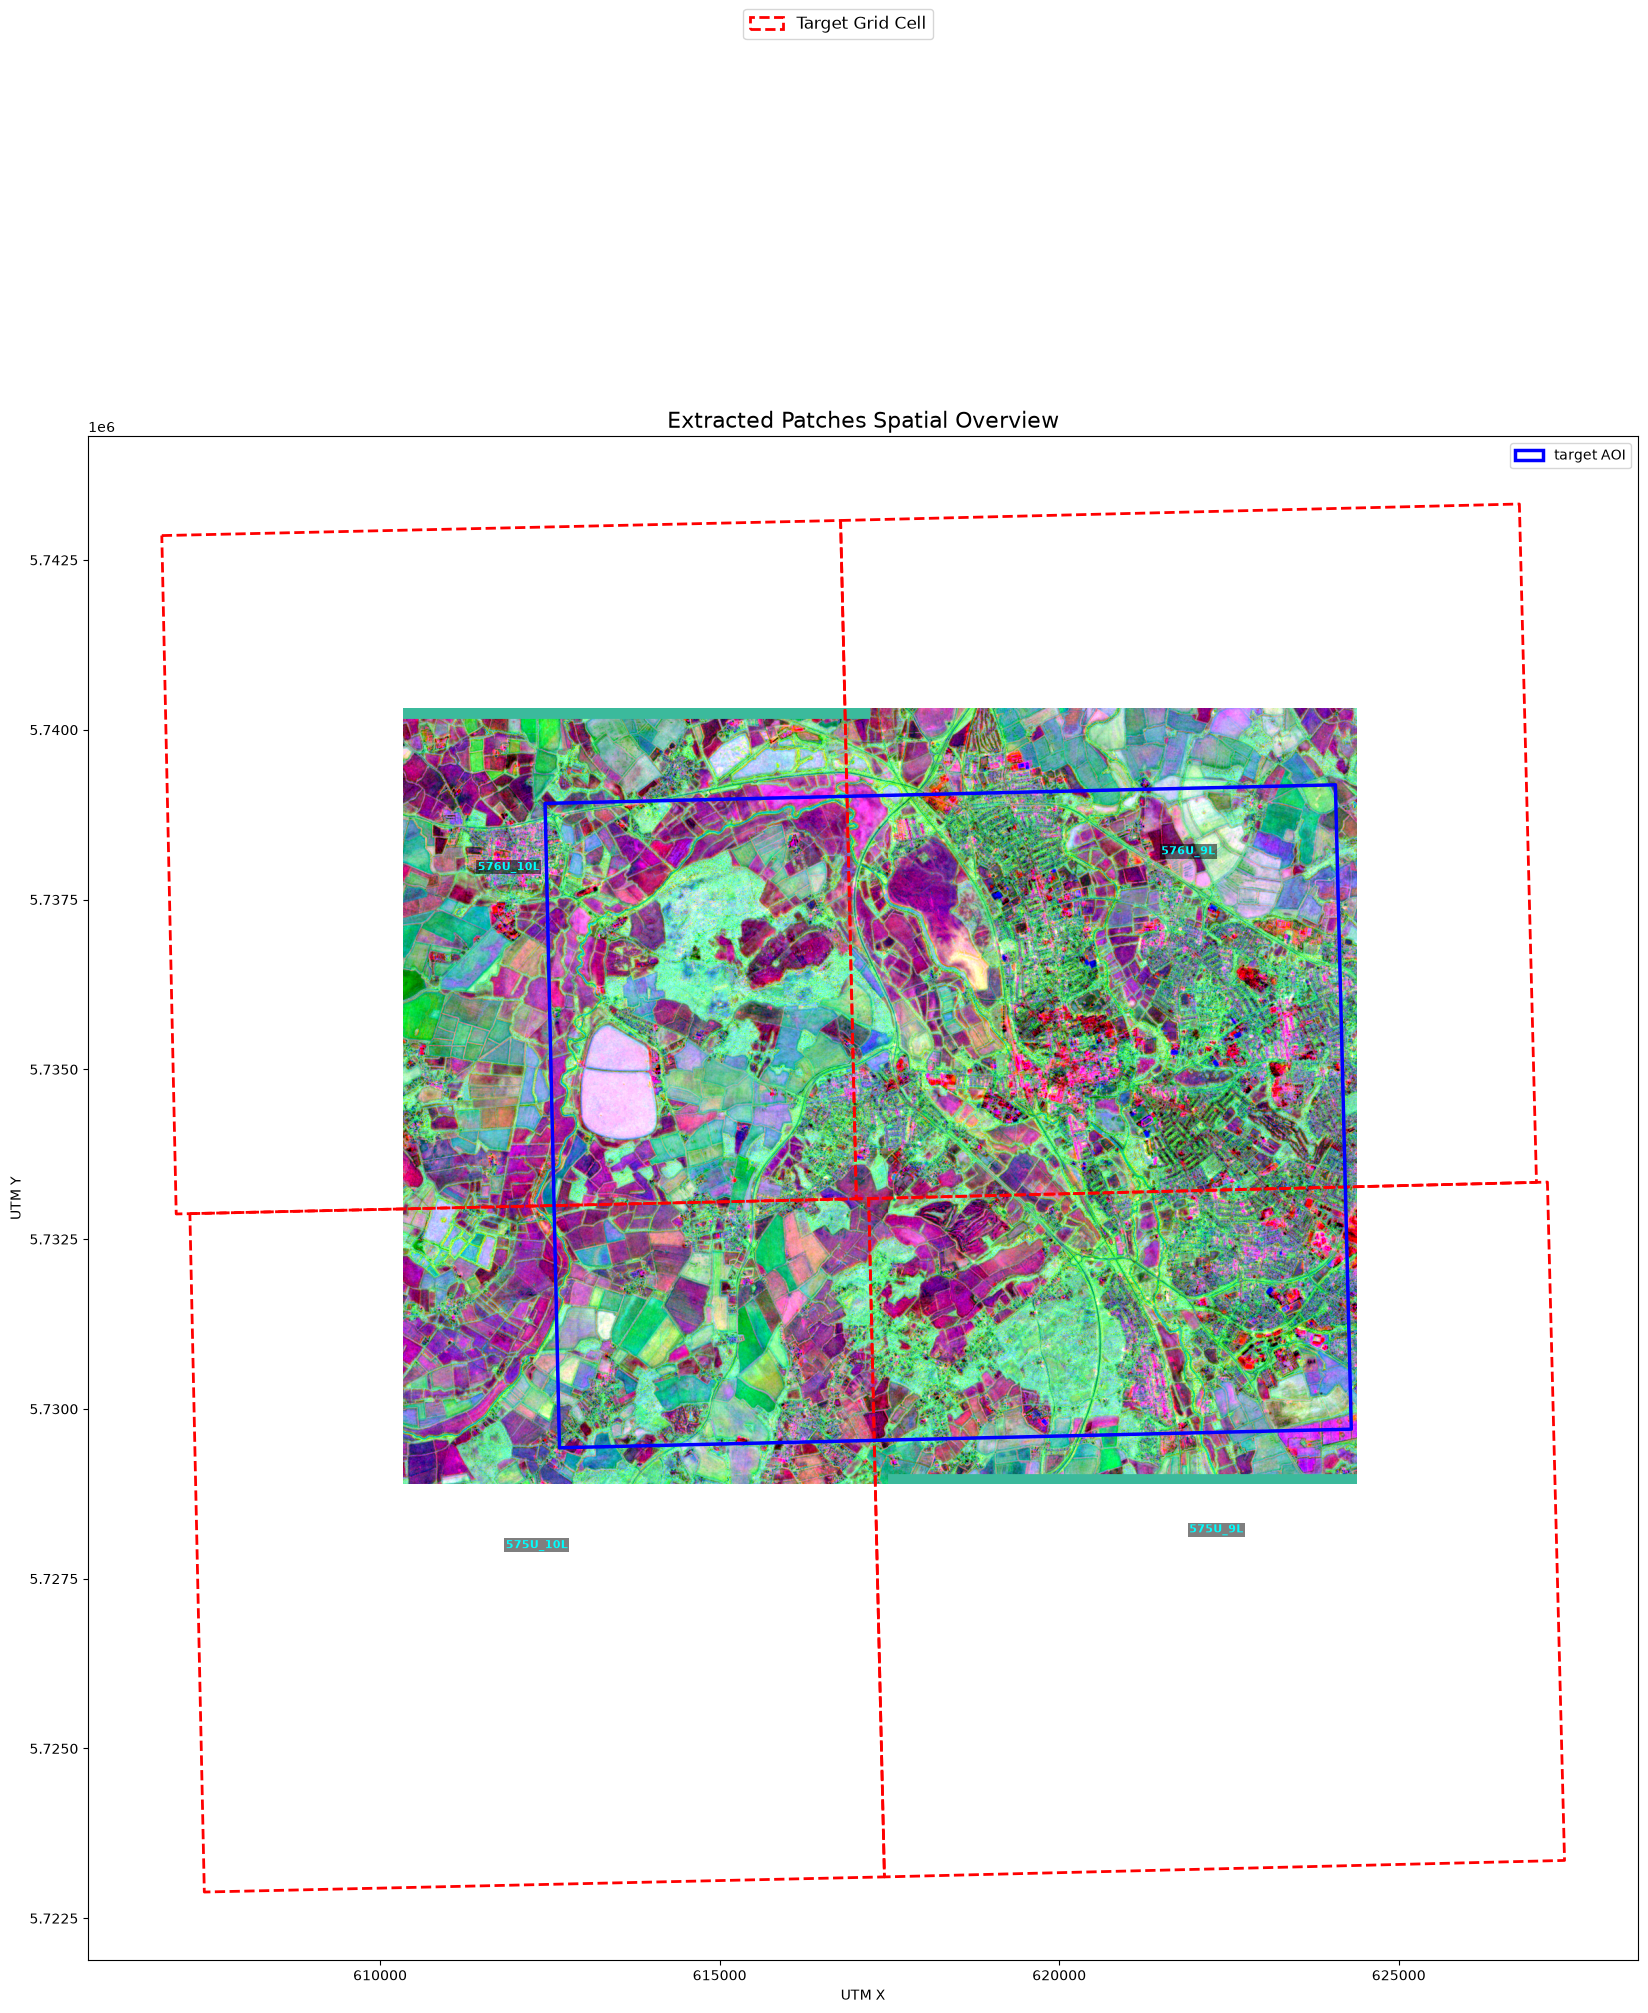

In [ ]:
from aereo.viz import plot_artifact_patches

fig, ax = plot_artifact_patches(
    artifacts, bands=[1, 2, 3], ds_factor=1, stretch="percentile", aoi=job.target_aoi
)

## Running the extraction

`job.execute(tasks, executor=...)` runs each task through the per-task pipeline: read GeoTessera tiles → reproject to 10 m → write GeoTIFF.


## Visualizing results

`plot_artifact_patches` renders the three-band output over the Oxford AOI.
